In [1]:
import numpy as np
import pandas as pd

In [2]:
train = pd.read_csv("customer_churn_dataset-training-master.csv")
test = pd.read_csv("customer_churn_dataset-testing-master.csv")

In [3]:
test.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [4]:
train.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [5]:
train.shape

(440833, 12)

In [6]:
train.dtypes

CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

In [7]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns', None)
train.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [32]:
train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Avg Spend Per Month
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,23.897436
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,11.367347
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,13.214286
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,10.421053
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,19.281250


In [9]:
target=train['Churn']

In [10]:
target.unique()

array([ 1.,  0., nan])

**Notes**

#### Churn Value Meaning
- **0 = Customer Stayed**
- **1 = Customer Left / Churned**

So, when we calculate `train["Churn"].mean()`, it gives the churn rate.

In [11]:
train.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [12]:
train[train.isnull().any(axis=1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
train=train.dropna()

In [14]:
train["Churn"].value_counts()

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

##### Approximately 56.7% of customers have churned, indicating a high customer attrition rate that requires further investigation.

In [15]:
train["Churn"].value_counts(normalize=True)

Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64

In [16]:
train.groupby("Contract Length")["Churn"].value_counts(normalize=True)

Contract Length  Churn
Annual           0.0      0.539239
                 1.0      0.460761
Monthly          1.0      1.000000
Quarterly        0.0      0.539744
                 1.0      0.460256
Name: proportion, dtype: float64

#### Contract Length Insight

Customers with **monthly contracts** show the highest churn rate, while annual and quarterly contracts show lower churn. This suggests that customers with shorter commitment periods are at much higher risk of leaving.

In [17]:
train.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [18]:
pd.crosstab(train["Subscription Type"],train["Churn"],normalize="index")

Churn,0.0,1.0
Subscription Type,,
Basic,0.418218,0.581782
Premium,0.440583,0.559417
Standard,0.439300,0.560700


#### Churn rates are relatively similar across all subscription types, with Basic showing only a slightly higher churn. This suggests that subscription type alone may not be a strong driver of customer churn.

In [19]:
train.groupby("Support Calls")["Churn"].mean()

Support Calls
0.0     0.302826
1.0     0.303630
2.0     0.315513
3.0     0.416431
4.0     0.584981
5.0     0.947147
6.0     1.000000
7.0     1.000000
8.0     1.000000
9.0     1.000000
10.0    1.000000
Name: Churn, dtype: float64

#### Churn increases sharply with the number of support calls, reaching nearly 100% for customers with 6 or more calls, suggesting that repeated support interactions may reflect unresolved problems leading to customer dissatisfaction.

In [20]:
train.groupby("Tenure")["Churn"].mean()

Tenure
1.0     0.653660
2.0     0.647148
3.0     0.634409
4.0     0.641387
5.0     0.645074
6.0     0.535306
7.0     0.545779
8.0     0.553325
9.0     0.537961
10.0    0.537529
11.0    0.541781
12.0    0.620232
13.0    0.628628
14.0    0.638240
15.0    0.630106
16.0    0.628119
17.0    0.636652
18.0    0.644923
19.0    0.633983
20.0    0.625936
21.0    0.631743
22.0    0.637880
23.0    0.624373
24.0    0.631779
25.0    0.530094
26.0    0.542801
27.0    0.542135
28.0    0.542368
29.0    0.543333
30.0    0.553806
31.0    0.534987
32.0    0.547138
33.0    0.537323
34.0    0.543026
35.0    0.545789
36.0    0.531689
37.0    0.540272
38.0    0.545584
39.0    0.543321
40.0    0.537570
41.0    0.541596
42.0    0.545478
43.0    0.541288
44.0    0.533036
45.0    0.539200
46.0    0.543880
47.0    0.542662
48.0    0.541166
49.0    0.534613
50.0    0.536809
51.0    0.550171
52.0    0.540868
53.0    0.540509
54.0    0.547200
55.0    0.553427
56.0    0.540963
57.0    0.545314
58.0    0.544921
59.0   

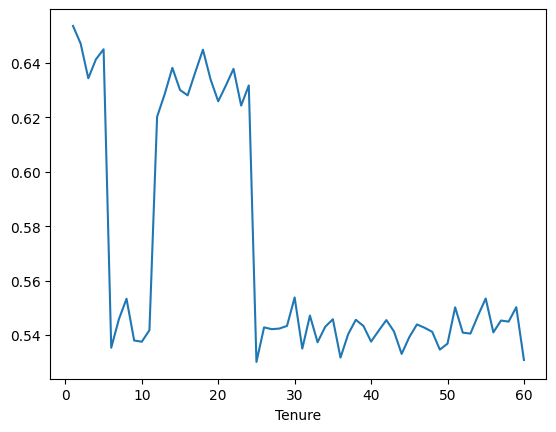

In [21]:
import matplotlib.pyplot as plt

train.groupby("Tenure")["Churn"].mean().plot()
plt.show()

#### Tenure Insight

Churn is highest among customers with very low tenure and becomes more stable after the early customer period. This suggests that early-stage retention is a key business challenge.

In [22]:
train.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [23]:
train.groupby("Churn")["Total Spend"].mean()

Churn
0.0    749.953111
1.0    541.285528
Name: Total Spend, dtype: float64

In [24]:
train["Avg Spend Per Month"] = train["Total Spend"] / train["Tenure"]

In [25]:
train.groupby("Churn")["Avg Spend Per Month"].mean()

Churn
0.0    50.399342
1.0    42.538850
Name: Avg Spend Per Month, dtype: float64

#### Spending Insight

Churned customers have lower total spend and lower average monthly spend, suggesting reduced engagement or lower perceived value before leaving.

## Predictive Modeling: Logistic Regression

A simple logistic regression model was built to predict whether a customer is likely to churn. The goal is not to create a perfect model, but to show an end-to-end analytics workflow: cleaning, feature engineering, encoding, model training, and evaluation.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [27]:
# Create a separate modeling dataframe so the original cleaned data remains unchanged
model_df = train.copy()

# CustomerID is only an identifier, so it should not be used for prediction
model_df = model_df.drop("CustomerID", axis=1, errors="ignore")

# Convert categorical columns into numeric columns for machine learning
model_df = pd.get_dummies(model_df, drop_first=True)

model_df.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Avg Spend Per Month,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,23.897436,False,False,True,False,False
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,11.367347,False,False,False,True,False
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,13.214286,False,False,False,False,True
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,10.421053,True,False,True,True,False
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,19.281250,True,False,False,True,False


In [28]:
X = model_df.drop("Churn", axis=1)
y = model_df["Churn"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

In [31]:
accuracy = model.score(X_test, y_test)
accuracy

0.8965032268309004

#### Model Insight

Built a logistic regression model to predict customer churn after performing data cleaning, exploratory analysis, feature engineering, and categorical encoding. The model achieved strong accuracy, showing that the selected customer behavior features are useful for churn prediction.

## Final Business Insights

1. **High overall churn:** Approximately 56.7% of customers churned, indicating a serious retention issue.
2. **Contract length matters:** Monthly contract customers show the highest churn, suggesting short-term customers are more likely to leave.
3. **Support calls are a strong churn signal:** Churn rises sharply as support calls increase, suggesting repeated support interactions may reflect unresolved problems.
4. **Early tenure customers are high-risk:** Customers in the initial tenure period show higher churn, making onboarding and early engagement important.
5. **Subscription type alone is not a strong driver:** Churn rates are similar across Basic, Standard, and Premium plans.
6. **Lower spend indicates lower engagement:** Churned customers show lower total spend and average monthly spend, suggesting reduced engagement before leaving.

## Business Recommendations

- Focus retention campaigns on **monthly contract customers**.
- Improve onboarding for **new customers with low tenure**.
- Monitor customers with **high support call counts** and prioritize issue resolution.
- Offer targeted upgrades, discounts, or value-added features to customers showing low spend or low engagement.
- Track churn risk regularly using customer behavior features such as support calls, tenure, contract length, and spend.